# Here they comes: the Selective classifiers!


In [19]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

import pickle

In [20]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [21]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [22]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "german_credit"
dt_name = "toy_dataset"

cf_method = 'ils'#dice or 'debug'


name_dataset = {"german_credit": "German Credit", 
                "adult": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [23]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz


In [24]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for toy_dataset
Loaded random_forest model from models/toy_dataset/random_forest.pkl
Loaded existing random_forest model
Processing mlp for toy_dataset
Loaded mlp model from models/toy_dataset/mlp.pkl
Loaded existing mlp model
Processing xgboost for toy_dataset
Loaded xgboost model from models/toy_dataset/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for toy_dataset
Loaded lgbm model from models/toy_dataset/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


## Load the distances files

In [25]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


Loaded ils/toy_dataset_ranking_latent.pkl
Loaded ils/toy_dataset_ranking_test_latent.pkl


In [26]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [27]:

# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats[k]['distances'][metric][stat] = np.array(all_stats[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats[k]['distances'][metric][stat]))
                for e in all_stats[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats[k]['probabs'] = np.array(all_stats[k]['probabs'])
    all_stats[k]['corrects'] = np.array(all_stats[k]['corrects']).reshape(-1)
    all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])

In [28]:
# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats_test[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats_test[k]['distances'][metric][stat] = np.array(all_stats_test[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats_test[k]['distances'][metric][stat]))
                for e in all_stats_test[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats_test[k]['probabs'] = np.array(all_stats_test[k]['probabs'])
    all_stats_test[k]['corrects'] = np.array(all_stats_test[k]['corrects']).reshape(-1)
    all_stats_test[k]['mean_conf'] = np.array(all_stats_test[k]['mean_conf'])

## There is a correlation?
Let's see the correlation between the distances (min, max, mean) and theprobability output of the model.


[0.         0.04761905 0.0952381  0.14285714 0.19047619 0.23809524
 0.28571429 0.33333333 0.38095238 0.42857143 0.47619048 0.52380952
 0.57142857 0.61904762 0.66666667 0.71428571 0.76190476 0.80952381
 0.85714286 0.9047619  0.95238095 1.        ]


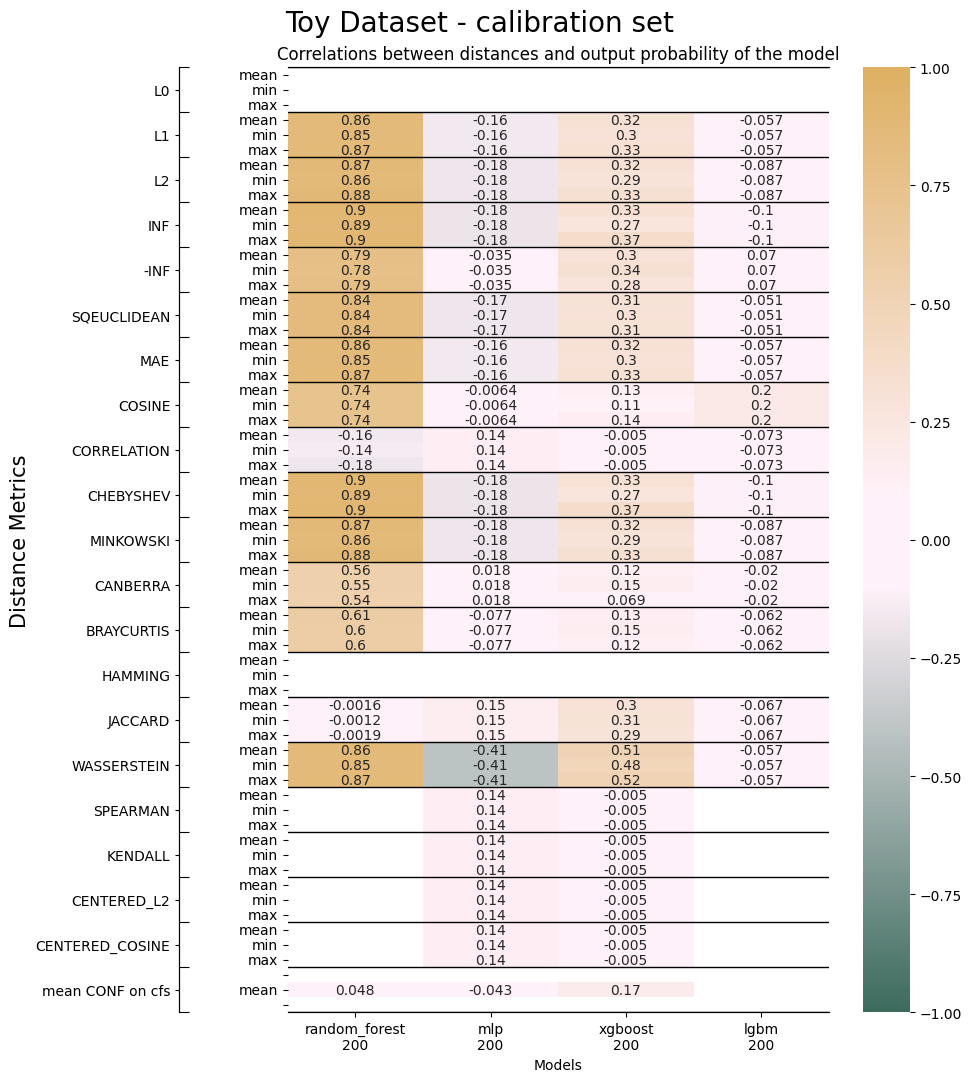

[0.         0.04761905 0.0952381  0.14285714 0.19047619 0.23809524
 0.28571429 0.33333333 0.38095238 0.42857143 0.47619048 0.52380952
 0.57142857 0.61904762 0.66666667 0.71428571 0.76190476 0.80952381
 0.85714286 0.9047619  0.95238095 1.        ]


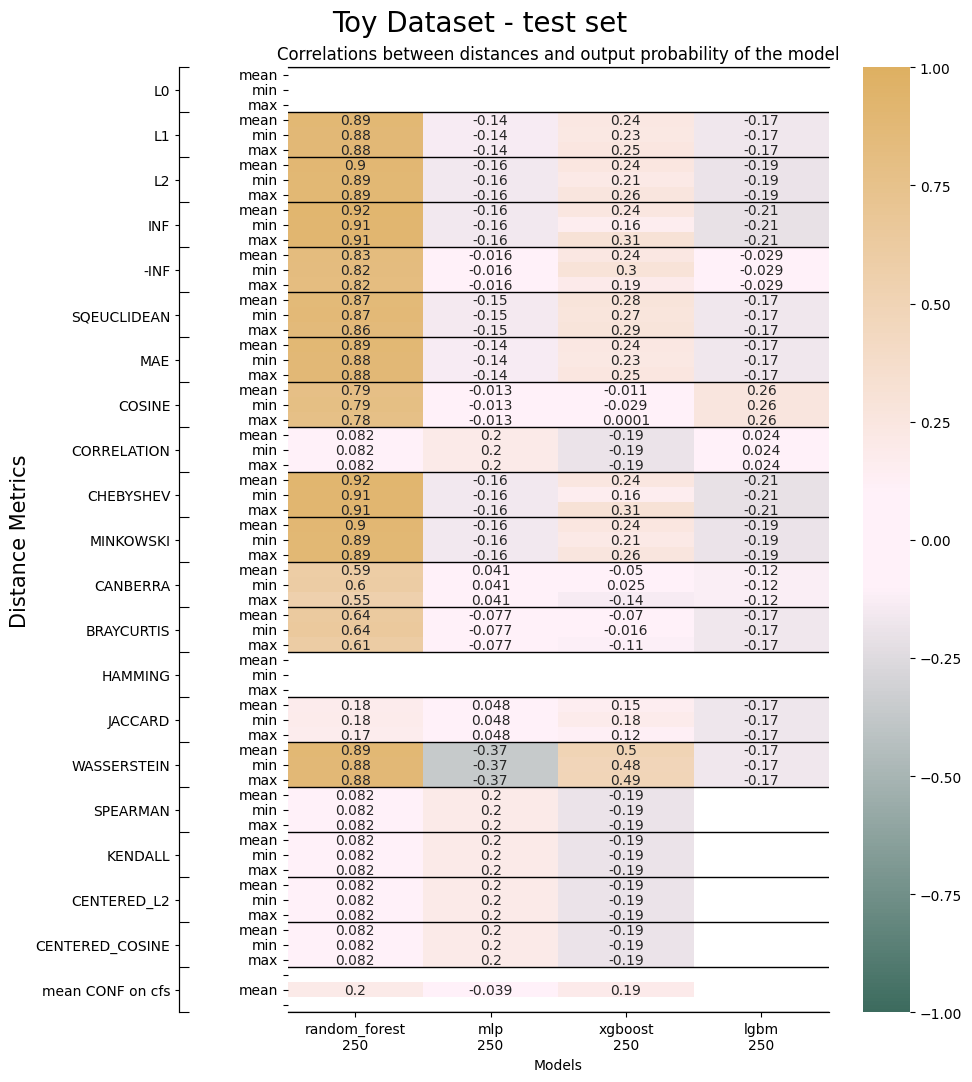

In [29]:

from matplotlib import ticker
    # Convert lists to numpy arrays first
for compute_test in [False,True]:
    all_stats_tmp = all_stats_test if compute_test else all_stats
    verbose = False
    correlations = {}
    metrics = list(all_stats_tmp[k]['distances'].keys())
    for metric in metrics:
        correlations[metric] = {}
        correlations["found_cfs"]={}
        for k in models.keys():
            
            mins  = all_stats_tmp[k]['distances'][metric]['min'][:]
            good_idxs = mins != np.inf
            mins = mins[good_idxs]
            maxs  = all_stats_tmp[k]['distances'][metric]['max'][:][good_idxs]
            means = all_stats_tmp[k]['distances'][metric]['mean'][:][good_idxs]
            probs = all_stats_tmp[k]['probabs'][:][good_idxs]
            if good_idxs.sum() == 0:
                print("No counterfactuals found for model",k,"and metric",metric)
                correlations[metric][k] = {"min":np.nan,"max":np.nan,"mean":np.nan}
                correlations["found_cfs"][k] = 0
                continue
            correlations[metric][k] = {}
            
            
            correlations[metric][k]["min"] = np.corrcoef(mins, probs.max(axis=1))[0,1]
            
            correlations[metric][k]["max"] = np.corrcoef(maxs, probs.max(axis=1))[0,1]
            correlations[metric][k]["mean"] = np.corrcoef(means, probs.max(axis=1))[0,1]
            if verbose:
                print(f"{metric} correlation for {k}:")
                print("Min", np.round(correlations[metric][k]["min"],3))
                print("Max", np.round(correlations[metric][k]["max"],3))
                print("Mean", np.round(correlations[metric][k]["mean"],3))
                print()
            correlations["found_cfs"][k] = good_idxs.sum()

    # lastly for each model let's compare the confidence of the model (probabs) with the mean confidence of the counterfactuals
    correlations["mean_conf"] = {}
    for k in models.keys():
        good_idx = all_stats_tmp[k]['distances']['l2']['min'] != np.inf
        if good_idx.sum() == 0:
            correlations["mean_conf"][k] = np.nan
        else:
            correlations["mean_conf"][k] = np.corrcoef(all_stats_tmp[k]['mean_conf'][good_idx[:]].max(axis=1), all_stats_tmp[k]['probabs'][good_idx[:]].max(axis=1))[0,1]

    # Create a bigger matrix for all metrics
    # Shape will be (3 * number_of_metrics, number_of_models)
    all_correlations = []
    for metric in metrics:
        metric_corr = []
        for stat in ["mean", "min", "max"]:
            row = [correlations[metric][model][stat] for model in models.keys()]
            metric_corr.append(row)
        all_correlations.extend(metric_corr)

    all_correlations.append([np.nan for model in models.keys()])
    all_correlations.append([correlations["mean_conf"][model] for model in models.keys()])
    all_correlations.append([np.nan for model in models.keys()])

    all_correlations = np.array(all_correlations)

    # Create labels for y-axis that include both metric and stat
    y_labels = []
    for metric in metrics:
        for stat in ["mean", "min", "max"]:
            y_labels.append(f"{stat}")
    y_labels.append("")
    y_labels.append("mean")
    y_labels.append("")
    total_metrics = len(metrics)+1
    rows_per_metric = 3

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, len(metrics)*0.55))
    gold_map_r = fplt.build_cmap(0.1, '#3c6b5e', '#fff1f9', '#deb062')
    sns.heatmap(all_correlations, annot=True, ax=ax, vmin=-1, vmax=1, cmap=gold_map_r)
    ax.set_yticks(0.5+np.arange(len(y_labels)),y_labels, rotation=0)
    ax.set_xticklabels([model+"\n"+str(correlations["found_cfs"][model]) for model in models.keys()])
    ax.set_title("Correlations between distances and output probability of the model")
    #plt.ylabel("Distance Metrics")
    plt.xlabel("Models")
    # Add horizontal lines between metric sections
    for i in range(total_metrics + 1):
        ax.axhline(y=i*rows_per_metric, color='black', linewidth=1)

    # Those are the ticks for the metrics's names
    ax_metrics = ax.twinx()
    ax_metrics.spines["left"].set_position(("axes", -0.2))
    ax_metrics.tick_params('both', length=3, direction='out', which='major')
    ax_metrics.yaxis.set_ticks_position("left")
    ax_metrics.yaxis.set_label_position("left")

    # Set metric positions and labels
    metric_positions = [(i * 3 + 1.5) for i in range(len(metrics)+1)]  # Center of each metric section
    ax_metrics.set_ylim(ax.get_ylim())
    ax_metrics.set_yticks(metric_positions)
    ax_metrics.set_yticklabels([m.upper() for m in metrics]+["mean CONF on cfs"])
    ax_metrics.set_ylabel("Distance Metrics", rotation=90,fontsize=15)

    # get anew axis
    ax_ = ax.twinx()
    ax_.spines["left"].set_position(("axes", -.2))

    ax_.tick_params('both', length=7, direction='in', which='major')
    ax_.yaxis.set_ticks_position("left")
    #ax_.yaxis.set_ticks_position("right")
    #ax_.yaxis.set_label_position("right")
    ticks_positions = (3*np.arange(0, len(metrics)+2))
    ticks_positions=ticks_positions/ticks_positions.max()
    print(ticks_positions)
    ax_.set_yticks(ticks_positions)
    ax_.set_yticklabels([""]*len(metrics)+[""]*2)

    ax_.spines["right"].set_visible(False)
    ax_metrics.spines["right"].set_visible(False)
    plt.suptitle(name_dataset+" - "+("test set" if compute_test else "calibration set"), fontsize=20)
    plt.tight_layout()
    # save the figure
    fig_name = os.path.join("plots",dt_name,
                            "Correlations_"+dt_name+"_"+("test" if compute_test else "cal")+"_"+cf_method+".pdf")
                            
    plt.savefig(fig_name)
    plt.savefig(fig_name.replace(".pdf",".png"))
    if True:#not compute_test:
        plt.show()
    else:
        plt.close(fig)

Text(0.5, 1.0, 'Max absolute correlation for each metric for Toy Dataset')

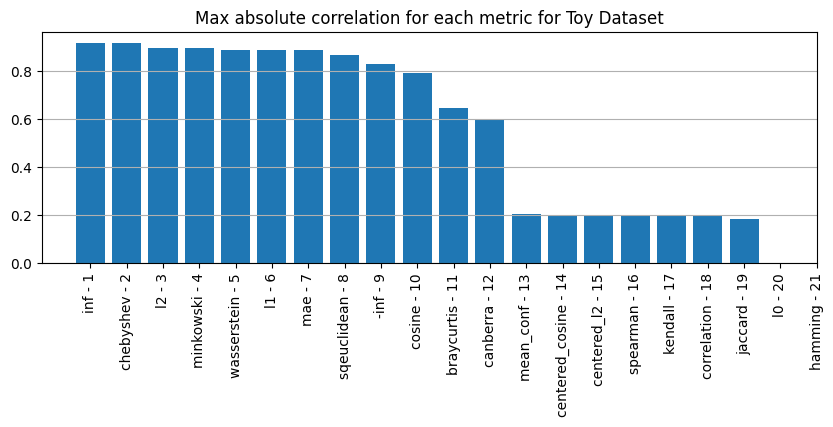

In [30]:
# choose the metric to plot
# for each metric take the max correlation amongthe min, mean and max for all the models
max_correlations = []

for j,m in enumerate(metrics):
    mmax = max([ abs(correlations[m][model]["min"]) for model in models.keys()] )
    mmean = max([abs(correlations[m][model]["mean"]) for model in models.keys()])
    Mmax = max([ abs(correlations[m][model]["max"]) for model in models.keys()] )
    # if any of the three is nan, place the -inf
    if np.isnan(mmax) or np.isnan(mmean) or np.isnan(Mmax):
        max_correlations.append((j,-np.inf))
    else:
        max_correlations.append((j,max([mmax,mmean,Mmax])))
max_correlations.append((j+1,max([abs(correlations["mean_conf"][model]) for model in models.keys()])))
max_correlations = np.array(sorted(max_correlations,key=lambda x: x[1],reverse=True))
np.array(metrics+["mean_conf"])[max_correlations[:,0].astype(int)]
#max_correlations[:5]
# make the plot very short
plt.figure(figsize=(10,3))

#plt.plot(max_correlations[:,1])
#use the bars
plt.bar(range(len(max_correlations)),max_correlations[:,1])
plt.xticks(range(len(max_correlations)),[m+" - " + str(j+1) for j,m in  enumerate(np.array(metrics+["mean_conf"])[max_correlations[:,0].astype(int)])],rotation=90)
plt.grid(axis='y')
max_correlations
plt.title("Max absolute correlation for each metric for "+name_dataset)



In [31]:
top_metrics = 8

focus_metrics = np.array(metrics+["mean_conf"])[max_correlations[:top_metrics,0].astype(int)]
focus_metrics = [fm for fm in focus_metrics if fm != "mean_conf"]

focus_metrics

['inf',
 'chebyshev',
 'l2',
 'minkowski',
 'wasserstein',
 'l1',
 'mae',
 'sqeuclidean']

In [32]:
#get the unbalancing
v,c = utl.print_balancing(splits["y_calibration"])
class_w = np.array(
    [1-c[i]/c.sum() for i,v1 in enumerate(v)]
)

utl.print_balancing(splits["y_test"])
utl.print_balancing(splits["y_train"])


Balancing: 200 samples
|██████████          | class 0: 100 (50.0%)
|          ██████████| class 1: 100 (50.0%)

Balancing: 250 samples
|██████████          | class 0: 125 (50.0%)
|          ██████████| class 1: 125 (50.0%)

Balancing: 550 samples
|██████████          | class 0: 275 (50.0%)
|          ██████████| class 1: 275 (50.0%)



(array([0, 1]), array([275, 275]))

In [33]:
# let's seek the outliers (if any) by using the iforest algorithm
from sklearn.ensemble import IsolationForest
anomaly_detector = IsolationForest(contamination=0.05,random_state=42)

anomaly_detector.fit(splits["X_train"])#,sample_weight=class_w[splits["y_train"]])
anomalies = anomaly_detector.predict(splits["X_calibration"])<0
print("Found",anomalies.sum(),"anomalies")

anomaly_detector2 = IsolationForest(contamination=0.05,random_state=42)
anomaly_detector2.fit(splits["X_train"],sample_weight=class_w[splits["y_train"]].reshape(-1))
anomalies2 = anomaly_detector2.predict(splits["X_calibration"])<0
print("Found",anomalies2.sum(),"anomalies with class weights")
anomalies_test = anomaly_detector.predict(splits["X_test"])<0
print("Found",anomalies_test.sum(),"anomalies in the test set")

Found 12 anomalies
Found 12 anomalies with class weights
Found 22 anomalies in the test set


max 6.755743 min 0.0060885698 max_ylim 8.983128943443297 min_ylim -0.05


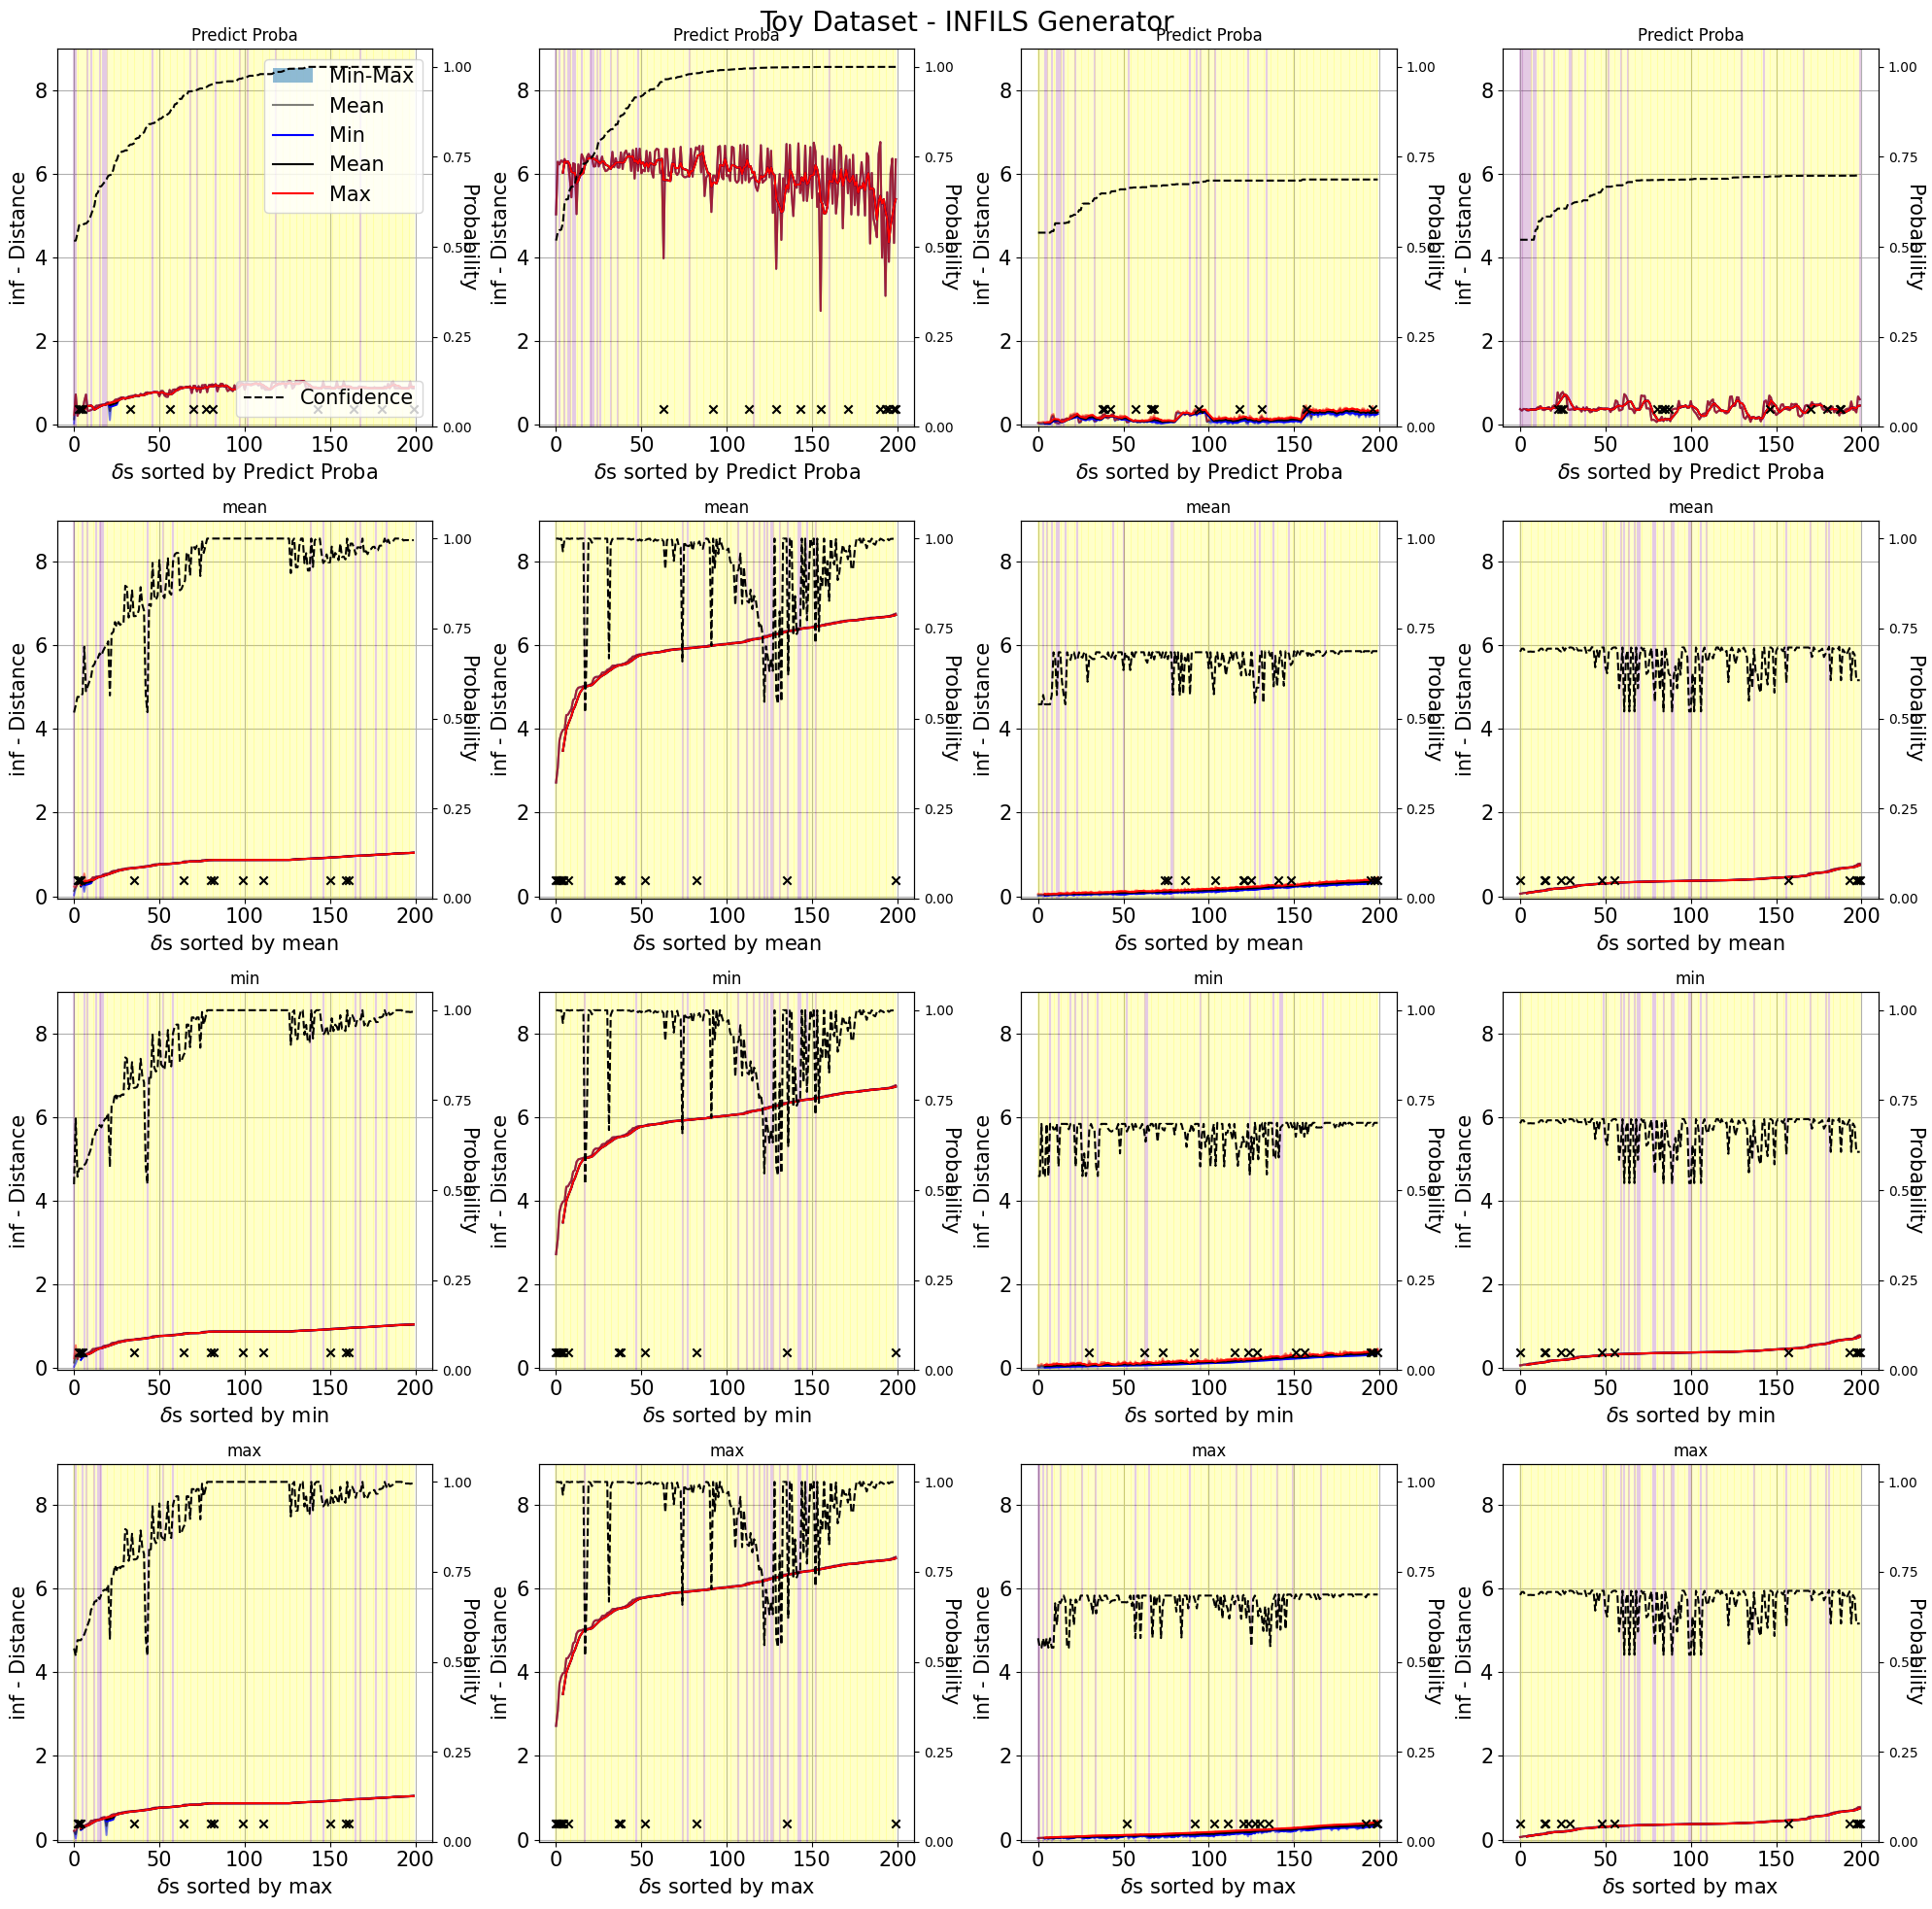

In [36]:
# now the plots!
# create 4 subplots
colors = {"min":"blue","max":"red","mean":"black"}
def create_plot_distances(dictionary,
                          metric = "l2",
                          sortby="mean",
                          axe=None,
                          title=None,
                          legend=False,colors = colors,
                          ylim = None):
    if axe == None:
        axe = plt.gca()

    min_color = colors["min"]
    max_color = colors["max"]
    mean_color = colors["mean"]

    argsorted = dictionary[sortby].argsort()
    rank_m = dictionary["min"][argsorted]
    rank_M = dictionary["max"][argsorted]
    rank_mean = dictionary["mean"][argsorted]
    
    if "correct" in dictionary.keys():
        rank_corrects = dictionary["correct"][argsorted]

        # shade the background with vertical lines colored by the corrects
        # if the model is correct the line is green, otherwise it's red
        # the alpha is 0.2, use axvline to plot the vertical lines
        for i in range(len(rank_corrects)):
            if rank_corrects[i]:
                axe.axvline(i,color="yellow",alpha=0.2)
            else:
                axe.axvline(i,color="purple",alpha=0.2)
        

    axe.fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axe.plot(rank_m,alpha=0.5,color=min_color)
    axe.plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axe.plot(rank_M,alpha=0.5,color=max_color)
    #axe.errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    axe.plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(5).mean(),label="Min",color=min_color)
    axe.plot(np.arange(len(rank_mean)),pd.Series(rank_mean).rolling(5).mean(),label="Mean",color=mean_color)
    axe.plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(5).mean(),label="Max",color=max_color)

    if legend:
        axe.legend(fontsize=15)
    axe.set_xlabel("$\delta$s sorted by "+sortby,fontsize=15)
    axe.set_ylabel(metric+" - Distance",fontsize=15)
    if title is not None:
        axe.set_title(title,fontsize=18)
    axe.grid()
    if ylim is not None:
        ylims = axe.get_ylim()

        axe.set_ylim(ylim[0],ylim[1])
        
    if "Predict Proba" in dictionary.keys():
        ax2 = axe.twinx()
        rank_prob = dictionary["Predict Proba"][argsorted]
        ax2.plot(np.arange(len(rank_m)),rank_prob,label="Confidence",color="black",linestyle="--")
        ax2.set_ylim(0,1.05)
        ax2.set_ylabel("Probability",fontsize=15,rotation=270)
        ax2.set_yticks(np.arange(0,1.1,0.25))
        if legend:
            # location is lower right
            ax2.legend(fontsize=15,loc="lower right")

        # get another x axes
    else:
        ax2 = axe.twiny()
        # place some ticks x shaped in correspondence of the anomalies
    if len(argsorted)== len(anomalies):
        ax2.scatter(np.arange(len(rank_m))[anomalies[argsorted]],
                 0.05*np.ones(anomalies.sum()),
                 marker="x",color="black",label="Anomalies")
    else:
        ax2.scatter(np.arange(len(rank_m))[anomalies_test[argsorted]],
                 0.05*np.ones(anomalies_test.sum()),
                 marker="x",color="black",label="Anomalies test")

    axe.set_title(sortby)
    five_perc = int(len(rank_m)*0.05)
    axe.set_xlim([-five_perc,len(rank_m)+five_perc])
    axe.xaxis.set_tick_params(labelsize=15)
    axe.yaxis.set_tick_params(labelsize=15)
    # tight layout
    plt.tight_layout()
    return axe


for metric in focus_metrics:
    fig, axs = plt.subplots(4, 4, figsize=(20, 20))
    axs = axs.flatten()
    # each model goes in a different subplot
    # we plot the sorted values of the minimum and the maximum distances,
    # then we shade the area between them. On top of that we plot the mean
    # at each data point we plot a vertical line with the std value of the distances, centeed at the mean
    c=0
    max_ = np.max([pd.Series(all_stats[k]["distances"][metric]["max"][
                   pd.Series(all_stats[k]["distances"][metric]["max"]).apply(np.isfinite)
                             ]).max(skipna=True)
                   for k in models.keys()])
    min_ = np.min([pd.Series(all_stats[k]["distances"][metric]["min"][
                   pd.Series(all_stats[k]["distances"][metric]["min"]).apply(np.isfinite)
                             ]).min(skipna=True)
                   for k in models.keys()])
    
    data_range = max_ - min_
    #make the the max_ylim so that the max value goes at the 67% of the plot
    max_ylim = max_ + (data_range * 0.33)  # Add 33% of range above max
    min_ylim = min_ - (data_range * 0.1)   # Subtract 10% of range below min
    min_ylim = max(-0.05,min_ylim)
    #max_ylim = min(20,max_ylim)
    #min_ylim = max(0,min_ylim)
    print("max",max_,"min",min_,"max_ylim",max_ylim,"min_ylim",min_ylim)
    for name in ["Predict Proba"]+["mean","min","max"]:
        for k in models.keys():
            create_plot_distances(dictionary={
                                    "mean":all_stats[k]["distances"][metric]["mean"],
                                    "std":all_stats[k] ["distances"][metric]["std"] ,
                                    "min":all_stats[k] ["distances"][metric]["min"] ,
                                    "max":all_stats[k] ["distances"][metric]["max"] ,
                                    "Predict Proba":all_stats[k]["probabs"].max(axis=1),
                                    "correct":all_stats[k]["corrects"]
                                    },
                            metric = metric,
                            sortby=name,
                            axe=axs[c],
                            title="model is "+k,
                            legend=(True if c==0 else False ),#%4== 0 else False),
                            ylim = (min_ylim,max_ylim))
            # create_plot_distances(dictionary={
            #                         "mean":all_stats_test[k]["distances"][metric]["mean"],
            #                         "std":all_stats_test[k] ["distances"][metric]["std"],
            #                         "min":all_stats_test[k] ["distances"][metric]["min"],
            #                         "max":all_stats_test[k] ["distances"][metric]["max"],
            #                         "Predict Proba":all_stats_test[k]["probabs"].max(axis=1),
            #                         "correct":all_stats_test[k]["corrects"]
            #                         },
            #                 metric = metric,
            #                 sortby=name,
            #                 axe=axs[c],
            #                 title="model is "+k,
            #                 legend=False,#%4== 0 else False),
            #                 ylim = (min_ylim,max_ylim))
            c+=1
    date = time.strftime("%Y-%m-%d")
    plt.suptitle(name_dataset+" - "+metric.upper()+ cf_method.upper()+" CF Generator",fontsize=20)
    plt.tight_layout()
    #fig_name = os.path.join("plots",dt_name,
    #                        "counterfactuals_dice_"+dt_name+"_"+date+"_"+metric+".pdf")
    
    #plt.savefig(fig_name)
    #print("Saved Figure at ",fig_name)
    if True:#metric == focus_metrics[-1]:
        plt.show()
    plt.close(fig)
    break

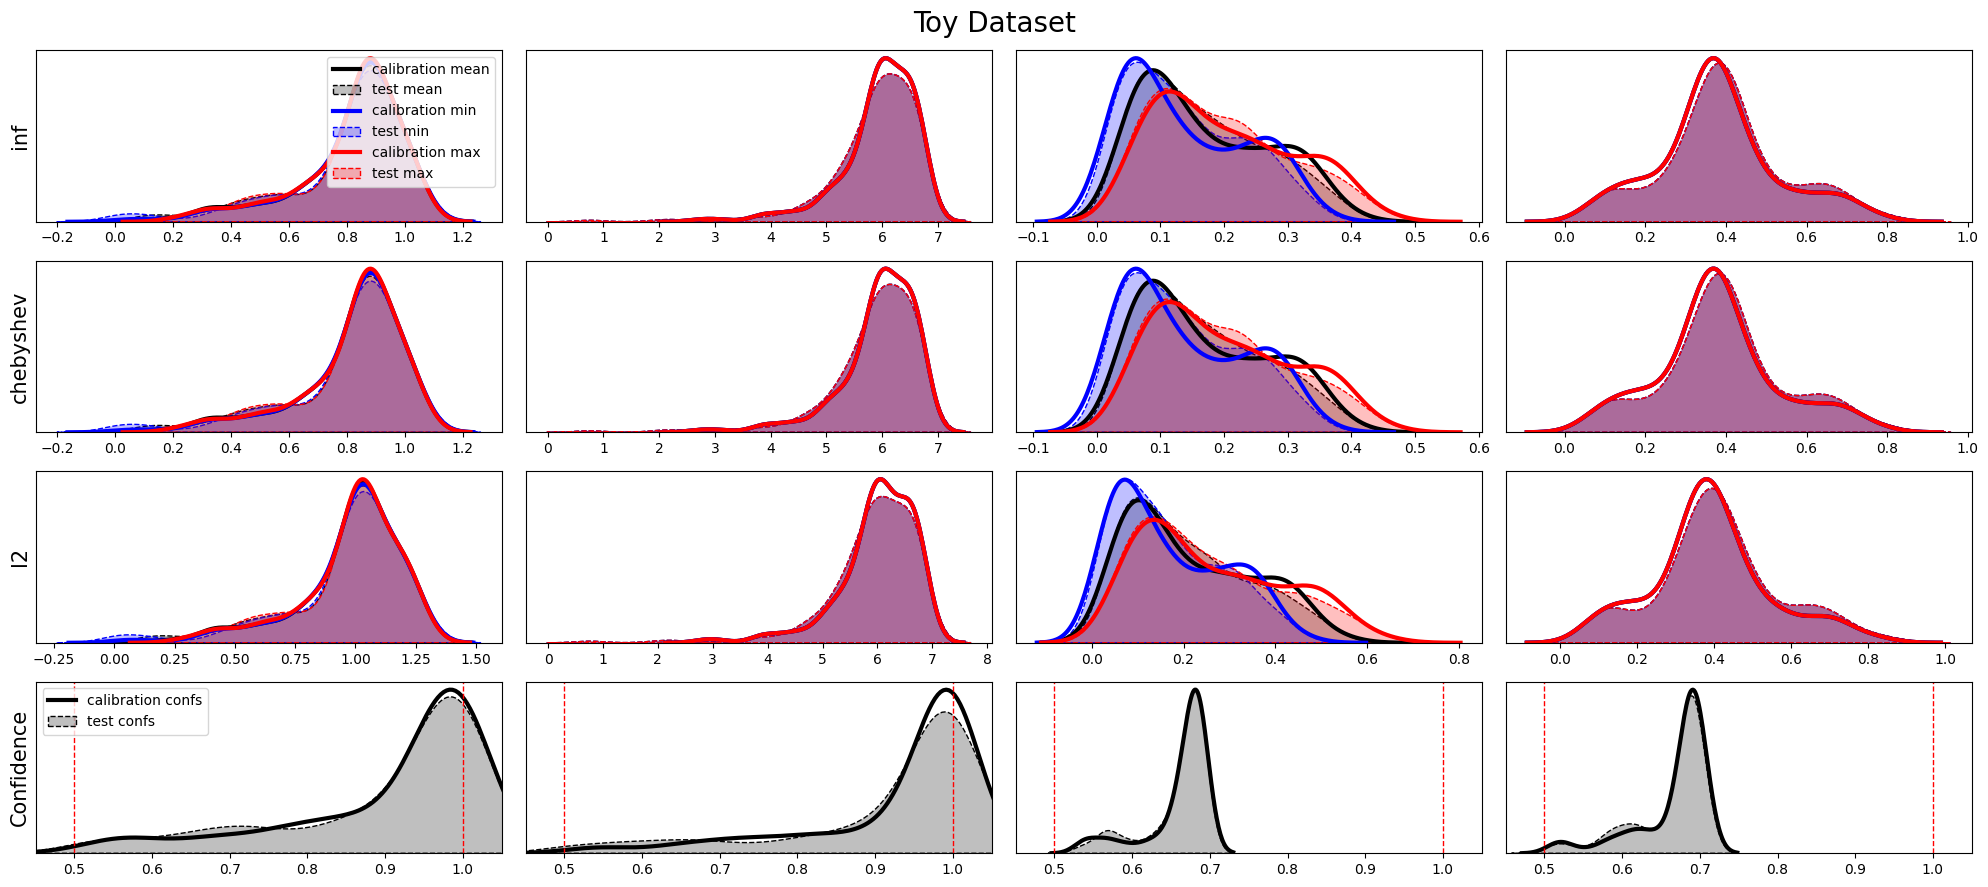

In [37]:
cumulative = False
top_k = 3
# colors = {"min":"blue","max":"red","mean":"black"}
fig, axs = plt.subplots(top_k+1,4, figsize=(20, 3*top_k))
axs = axs.flatten()
for i,metric in enumerate(focus_metrics[:top_k]):
    for name in ["mean","min","max"]:
        for j,k in enumerate(models.keys()):
            indx = 4*i+j
            # plot the distribution of the distances (calibration and test)
            sns.kdeplot(all_stats[k]["distances"][metric][name],ax=axs[indx],cumulative=cumulative,
                    label='calibration '+name,lw=3,color=colors[name])
            sns.kdeplot(all_stats_test[k]["distances"][metric][name],ax=axs[indx],cumulative=cumulative,
                    label='test '+name,ls="--",color=colors[name],fill=True)
    if i == 0:
        axs[0].legend(loc = "upper right")
    # remove the y ticks and the y labels
for j,ax in enumerate(axs):
    ax.yaxis.set_ticks([])
    ax.yaxis.set_ticklabels([])
    if j % 4 == 0 and j<=4*top_k:
        ax.yaxis.set_ticks_position("left")
        ax.yaxis.set_label_position("left")
        ax.set_ylabel(focus_metrics[j//4],fontsize=15)
        ax.yaxis.set_tick_params(labelsize=15)
    else:
        ax.set_ylabel("")
for indx,k in enumerate(models.keys()):
    indx+=4*top_k
    sns.kdeplot(all_stats[k]["probabs"].max(axis=1),ax=axs[indx],cumulative=cumulative,
                    label='calibration confs',lw=3,color="k")
    sns.kdeplot(all_stats_test[k]["probabs"].max(axis=1),ax=axs[indx],cumulative=cumulative,
                    label='test confs',ls="--",color='k',fill=True)
    axs[indx].set_xlim(0.45,1.05)
    # plot vertical lines at 0.5 and 1.0
    axs[indx].axvline(0.5,color="red",lw=1,ls='--')
    axs[indx].axvline(1.0,color="red",lw=1,ls='--')
    if indx % 4 == 0:
        axs[indx].legend(loc = "upper left")
        axs[indx].set_ylabel("Confidence",fontsize=15)
    
date = time.strftime("%Y-%m-%d")
plt.suptitle(name_dataset,fontsize=20)
plt.tight_layout()
fig_name = os.path.join("plots",dt_name,
                        "distributions"+dt_name+"_"+metric+".pdf")
plt.savefig(fig_name)
plt.show()       
plt.close(fig)
    